<a href="https://colab.research.google.com/github/springboardmentor123g/PlantDocBotProject/blob/Intern-UjjwalKumar/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
from PIL import Image
import os
import random

In [2]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".." + path + "/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_path = path + "/train"
valid_path = path + "/valid"

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


Potato___Early_blight
256
256


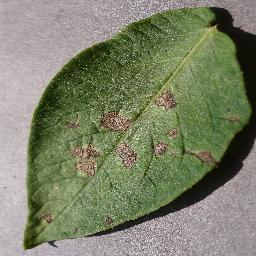

In [3]:
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
random_class_name = random.choice(classes)
random_class_path = os.path.join(train_path, random_class_name)
random_image_name = random.choice(os.listdir(random_class_path))
random_image_path = os.path.join(random_class_path, random_image_name)

img = Image.open(random_image_path)
print(random_class_name)
print(img.width)
print(img.height)
img

In [4]:
!nvidia-smi

Fri Jan  9 11:37:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch

In [6]:
# device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
random_image = torch.rand(3, 256, 256)
random_image

tensor([[[1.9757e-01, 1.8075e-01, 3.2712e-01,  ..., 4.4580e-01,
          9.7650e-01, 4.8797e-01],
         [3.7173e-01, 3.5107e-01, 5.3233e-01,  ..., 3.1378e-01,
          2.7054e-01, 9.6453e-02],
         [1.8992e-01, 3.7466e-01, 8.8037e-01,  ..., 6.1607e-01,
          5.2496e-01, 9.3797e-02],
         ...,
         [2.7589e-01, 6.5394e-01, 4.0178e-01,  ..., 6.5481e-01,
          2.8699e-01, 6.9144e-01],
         [3.1503e-03, 9.0536e-02, 7.4615e-01,  ..., 6.8498e-01,
          9.9631e-01, 2.1335e-01],
         [5.0236e-01, 7.1968e-02, 8.2308e-01,  ..., 4.2652e-01,
          4.6832e-01, 8.9964e-01]],

        [[5.9170e-01, 1.0082e-01, 3.0108e-02,  ..., 8.1535e-01,
          2.0472e-01, 3.0979e-01],
         [9.7751e-01, 6.0936e-01, 3.4420e-01,  ..., 7.9688e-01,
          4.2702e-01, 6.5580e-02],
         [5.1881e-01, 2.9314e-02, 5.7496e-01,  ..., 5.7604e-01,
          4.1844e-01, 4.8750e-01],
         ...,
         [2.0763e-01, 6.7804e-01, 3.2536e-01,  ..., 6.6012e-01,
          9.777

In [8]:
random_image.device

device(type='cpu')

In [9]:
random_image.cpu()

tensor([[[1.9757e-01, 1.8075e-01, 3.2712e-01,  ..., 4.4580e-01,
          9.7650e-01, 4.8797e-01],
         [3.7173e-01, 3.5107e-01, 5.3233e-01,  ..., 3.1378e-01,
          2.7054e-01, 9.6453e-02],
         [1.8992e-01, 3.7466e-01, 8.8037e-01,  ..., 6.1607e-01,
          5.2496e-01, 9.3797e-02],
         ...,
         [2.7589e-01, 6.5394e-01, 4.0178e-01,  ..., 6.5481e-01,
          2.8699e-01, 6.9144e-01],
         [3.1503e-03, 9.0536e-02, 7.4615e-01,  ..., 6.8498e-01,
          9.9631e-01, 2.1335e-01],
         [5.0236e-01, 7.1968e-02, 8.2308e-01,  ..., 4.2652e-01,
          4.6832e-01, 8.9964e-01]],

        [[5.9170e-01, 1.0082e-01, 3.0108e-02,  ..., 8.1535e-01,
          2.0472e-01, 3.0979e-01],
         [9.7751e-01, 6.0936e-01, 3.4420e-01,  ..., 7.9688e-01,
          4.2702e-01, 6.5580e-02],
         [5.1881e-01, 2.9314e-02, 5.7496e-01,  ..., 5.7604e-01,
          4.1844e-01, 4.8750e-01],
         ...,
         [2.0763e-01, 6.7804e-01, 3.2536e-01,  ..., 6.6012e-01,
          9.777

In [10]:
# torch.matmul()
torch.max(random_image) #random_image is a single tensor, you cannot directly use torch.matmul(random_image) because torch.matmul requires two tensors.

tensor(1.0000)

In [11]:
# How to create a pytorch model and how to write a training loop
# We will be subclassing nn.Module.

In [12]:
import torch
import torch.nn as nn

In [13]:
#y=mX + c

In [14]:
weight, bias = 0.5, 0.4

In [15]:
X = torch.arange(0, 2, 0.02)
y = weight * X + bias

In [16]:
class SampleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  def forward(self, x):
    return (self.weights * x) + self.bias

In [17]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [18]:
torch.manual_seed(42)
model=SampleModel()

In [19]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [20]:
from matplotlib import pyplot as plt

In [21]:
def plot_predictions(X_train, y_train, X_test, y_test, y_preds=None):
  plt.scatter(X_train, y_train, c="b")
  plt.scatter(X_test, y_test, c="g")
  if y_preds is not None:
    plt.scatter(X_test, y_preds, c="r")


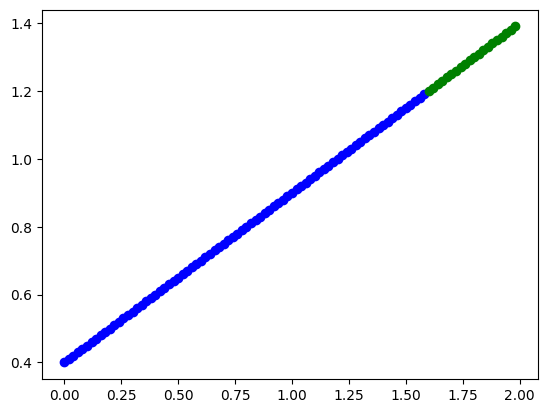

In [22]:
plot_predictions(X_train, y_train, X_test, y_test)

In [23]:
with torch.inference_mode():
  y_preds = model(X_test)

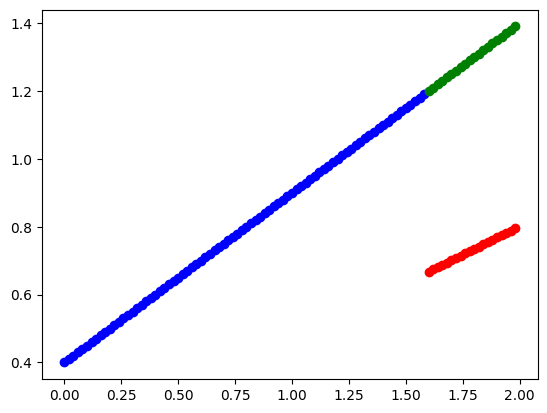

In [24]:
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [25]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(model.parameters(), lr=0.0001)

In [26]:
# perform the foward pass
# calculate the loss
# backpropagation
# update gradient

In [71]:
torch.manual_seed(42)
EPOCHS = 100
for epochs in range(EPOCHS):
  model.train()
  y_preds=model(X_train)
  loss=loss_fn(y_preds, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    y_test_preds=model(X_test)
    test_loss=loss_fn(y_test_preds, y_test)

  if epochs % 10 == 0:
    print(f"epoch: {epochs} | loss: {loss} | test_loss: {test_loss}")

epoch: 0 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 10 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 20 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 30 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 40 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 50 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 60 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 70 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 80 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 90 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918


In [72]:
with torch.inference_mode():
  y_preds = model(X_test)

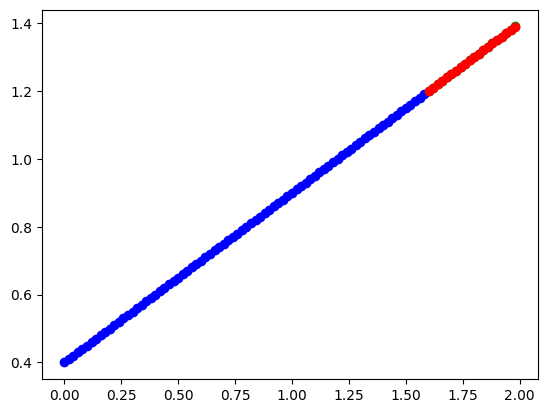

In [73]:
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [74]:
model.state_dict()

OrderedDict([('weights', tensor([0.5000])), ('bias', tensor([0.3999]))])

In [75]:
len(classes)

38

In [76]:
#from torch.utils.data we need Dataset, Dataloader

In [77]:
#from torchvision we need transforms, datasets

In [78]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models

In [79]:
dummy_transform = transforms.Compose([
    transforms.ToTensor()
])

In [80]:
type(dummy_transform)

torchvision.transforms.transforms.Compose

In [81]:
train_dataset = datasets.ImageFolder(train_path, transform=dummy_transform)


In [82]:
valid_dataset = datasets.ImageFolder(valid_path, transform=None)

In [83]:
print(type(valid_dataset))

<class 'torchvision.datasets.folder.ImageFolder'>


In [84]:
len(train_dataset),len(valid_dataset)

(70295, 17572)

In [85]:
transformed_img = dummy_transform(img)
transformed_img

tensor([[[0.6745, 0.6784, 0.6824,  ..., 0.5569, 0.5529, 0.5882],
         [0.6706, 0.6745, 0.6745,  ..., 0.5765, 0.5490, 0.5333],
         [0.6941, 0.6941, 0.6902,  ..., 0.6039, 0.5961, 0.5451],
         ...,
         [0.7843, 0.7529, 0.7255,  ..., 0.5098, 0.5255, 0.5686],
         [0.8000, 0.7608, 0.7333,  ..., 0.5451, 0.5569, 0.5961],
         [0.7804, 0.7647, 0.7569,  ..., 0.5882, 0.5765, 0.5804]],

        [[0.6314, 0.6353, 0.6392,  ..., 0.5098, 0.5059, 0.5412],
         [0.6275, 0.6314, 0.6314,  ..., 0.5294, 0.5020, 0.4863],
         [0.6510, 0.6510, 0.6471,  ..., 0.5569, 0.5490, 0.4980],
         ...,
         [0.7647, 0.7333, 0.7059,  ..., 0.4863, 0.5020, 0.5451],
         [0.7804, 0.7412, 0.7137,  ..., 0.5216, 0.5333, 0.5725],
         [0.7608, 0.7451, 0.7373,  ..., 0.5647, 0.5529, 0.5569]],

        [[0.6471, 0.6510, 0.6549,  ..., 0.5176, 0.5137, 0.5490],
         [0.6431, 0.6471, 0.6471,  ..., 0.5373, 0.5098, 0.4941],
         [0.6667, 0.6667, 0.6627,  ..., 0.5647, 0.5569, 0.

In [86]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)

In [87]:
len(train_dataloader), len(valid_dataloader)

(2197, 550)

In [88]:
def compute_mean_std(dataset, batch_size=32, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, shuffle = False, num_workers=2)
  channel_sum = torch.zeros(3, device=device)
  channel_sqsum = torch.zeros(3, device=device)
  pixel_count = 0

  for x, _ in loader:
    x = x.to(device)
    b, c, h, w = x.shape
    pixel_count+= h * w * b
    channel_sum += x.sum(dim=[0, 2, 3])
    channel_sqsum += (x**2).sum(dim=[0, 2, 3])

  mean = channel_sum / pixel_count
  std = torch.sqrt(channel_sqsum/ pixel_count - mean ** 2)
  return  mean, std

In [89]:
mean, std = compute_mean_std(train_dataset)
mean, std

(tensor([0.4757, 0.5001, 0.4264], device='cuda:0'),
 tensor([0.2165, 0.1957, 0.2320], device='cuda:0'))

In [90]:
mean.tolist(), std.tolist()

([0.47568196058273315, 0.5001007318496704, 0.42636263370513916],
 [0.21649622917175293, 0.19567890465259552, 0.23202040791511536])

In [91]:
mean = [0.47568196058273315, 0.5001007318496704, 0.42636263370513916]
std =  [0.21649622917175293, 0.19567890465259552, 0.23202040791511536]

In [92]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [93]:
valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [94]:
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
valid_dataset = datasets.ImageFolder(root=valid_path, transform=valid_transform)

In [95]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle = False, num_workers=2)

In [96]:
class_to_idx = train_dataset.class_to_idx

In [97]:
idx_to_class = {b: a for a, b in class_to_idx.items()}
idx_to_class

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [98]:
# A Sample CNN

class SampleCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
        #112
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
        #56
    )

    self.block3 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
        #28
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= 128*28*28, out_features=512),
        nn.ReLU(),
        nn.Dropout(),
        nn.Linear(in_features=512, out_features=num_classes)
    )

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.classifier(x)
    return x



In [99]:
model = SampleCNN(num_classes=38).to(device)

In [100]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [101]:
torch.manual_seed(42)
EPOCHS = 3

for epoch in range(EPOCHS):
  print(f"EPOCH: {epoch+1}")
  print("-----------------")
  model.train()
  train_loss = 0
  valid_loss = 0

  for images, labels in train_dataloader:
    images, labels = images.to(device), labels.to(device)

    label_preds = model(images)

    loss = loss_fn(label_preds, labels)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(train_dataloader)

  model.eval()
  with torch.inference_mode():
    for images, labels in valid_dataloader:
      images, labels = images.to(device), labels.to(device)
      valid_preds = model(images)
      t_loss = loss_fn(valid_preds, labels)
      valid_loss += t_loss.item()
    valid_loss /= len(valid_dataloader)
  print(f"train loss: {train_loss} | validation loss: {valid_loss}")




EPOCH: 1
-----------------
train loss: 1.34338688287455 | validation loss: 0.45452875576437113
EPOCH: 2
-----------------
train loss: 0.4954931500944757 | validation loss: 0.2559352883756153
EPOCH: 3
-----------------
train loss: 0.35410271140140165 | validation loss: 0.2340787199357236


In [102]:
model.eval()


SampleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352,

In [103]:
def check_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy


In [104]:
train_acc = check_accuracy(model, train_dataloader, device)
val_acc = check_accuracy(model, valid_dataloader, device)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")


Train Accuracy: 0.9371
Validation Accuracy: 0.9232


In [105]:
model_conv = models.resnet18(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


In [106]:
num_classes = len(train_dataset.classes)
num_classes

38

In [107]:
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, num_classes)

In [108]:
torch.manual_seed(42)
EPOCHS = 5

for epoch in range(EPOCHS):
  print(f"EPOCH: {epoch+1}")
  print("-----------------")
  model_conv.train()
  train_loss = 0
  valid_loss = 0

  for images, labels in train_dataloader:
    images, labels = images.to(device), labels.to(device)

    label_preds = model(images)

    loss = loss_fn(label_preds, labels)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(train_dataloader)

  model_conv.eval()
  with torch.inference_mode():
    for images, labels in valid_dataloader:
      images, labels = images.to(device), labels.to(device)
      valid_preds = model(images)
      t_loss = loss_fn(valid_preds, labels)
      valid_loss += t_loss.item()
    valid_loss /= len(valid_dataloader)
  print(f"train loss: {train_loss} | validation loss: {valid_loss}")




EPOCH: 1
-----------------
train loss: 0.14092287648016477 | validation loss: 0.14489862306696075
EPOCH: 2
-----------------
train loss: 0.11707896521923497 | validation loss: 0.19361150133209978
EPOCH: 3
-----------------
train loss: 0.10457676235413875 | validation loss: 0.18602985633292912
EPOCH: 4
-----------------
train loss: 0.10540439905332759 | validation loss: 0.13189690529379383
EPOCH: 5
-----------------
train loss: 0.10115643205866387 | validation loss: 0.20987538924911905


In [109]:
model_conv.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [110]:
def check_accuracy(model_conv, dataloader, device):
    model_conv.eval()
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy


In [111]:
model_conv.to(device)
train_acc = check_accuracy(model_conv, train_dataloader, device)
val_acc = check_accuracy(model_conv, valid_dataloader, device)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Train Accuracy: 0.9580
Validation Accuracy: 0.9364


In [112]:
model_efficientnet_b4 = models.efficientnet_b4(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 156MB/s]


In [113]:
import torch.nn as nn

num_ftrs = model_efficientnet_b4.classifier[1].in_features

model_efficientnet_b4.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs, num_classes)
)


In [114]:
torch.manual_seed(42)
EPOCHS = 10

for epoch in range(EPOCHS):
  print(f"EPOCH: {epoch+1}")
  print("-----------------")
  model_efficientnet_b4 .train()
  train_loss = 0
  valid_loss = 0

  for images, labels in train_dataloader:
    images, labels = images.to(device), labels.to(device)

    label_preds = model(images)

    loss = loss_fn(label_preds, labels)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(train_dataloader)

  model_efficientnet_b4.eval()
  with torch.inference_mode():
    for images, labels in valid_dataloader:
      images, labels = images.to(device), labels.to(device)
      valid_preds = model(images)
      t_loss = loss_fn(valid_preds, labels)
      valid_loss += t_loss.item()
    valid_loss /= len(valid_dataloader)
  print(f"train loss: {train_loss} | validation loss: {valid_loss}")




EPOCH: 1
-----------------
train loss: 0.0729909993864754 | validation loss: 0.19239593933543245
EPOCH: 2
-----------------
train loss: 0.06867556106041192 | validation loss: 0.13431322107959562
EPOCH: 3
-----------------
train loss: 0.07046340553150696 | validation loss: 0.14493579966008285
EPOCH: 4
-----------------
train loss: 0.06656077395661884 | validation loss: 0.16321491581490466
EPOCH: 5
-----------------
train loss: 0.0767226220665754 | validation loss: 0.20924710549899853
EPOCH: 6
-----------------
train loss: 0.07045373377370912 | validation loss: 0.1341961958049787
EPOCH: 7
-----------------
train loss: 0.06771499510567763 | validation loss: 0.10919463784961966
EPOCH: 8
-----------------
train loss: 0.0695292537262436 | validation loss: 0.15519155436819496
EPOCH: 9
-----------------
train loss: 0.0694125335150439 | validation loss: 0.11441514166623738
EPOCH: 10
-----------------
train loss: 0.06972535142812147 | validation loss: 0.215929917578937


In [115]:
model_efficientnet_b4.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [116]:
def check_accuracy(model_efficientnet_b4, dataloader, device):
    model_efficientnet_b4.eval()
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy


In [117]:
model_efficientnet_b4.to(device)
train_acc = check_accuracy(model_efficientnet_b4, train_dataloader, device)
val_acc = check_accuracy(model_efficientnet_b4, valid_dataloader, device)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Train Accuracy: 0.9676
Validation Accuracy: 0.9472


In [118]:
MODEL_PATH = "efficientnet_b4.pth"

# Save model weights
torch.save(model_efficientnet_b4.state_dict(), MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!
